In [1]:
#--LIBRARIES--------
import eelib
from eelib import pi
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [2]:
#--PARAMETERS--------

# note that k, B, and R are percents here, mu is not as its scale is unknown
dk = 0.5
R  = 0.8
B  = 0.5
mu = 5e-5

tf_sm = 1e-8
tf_full = 2*pi*R * 1e-6

This is a test of decreasing the tolerance of the integrator, and measuring the resulting distribution of absolute value peaks.

In [3]:
rtol = 2.0e-12
atol = 1.0e-17
plot_code = -2

n_pts = 200

In [10]:
mu_r = (1e-5, 5e-4)
b_r = (0.01, 1.0)
r_r = (0.57, 1.0)
dk_r = (0.1, 0.9)
n_plots = 150

#mu = (1.0, 1.0), dk = (-1.0, -1.0), B = (-1.0, -1.0), R = (-1.0, -1.0), 
grid_val = eelib.grid_fast_osc(R, B, dk, mu)
grid_val.makeMCPoints(mu=mu_r, dk = dk_r, B=b_r, R = r_r, num = n_plots)
val_table = grid_val.val_table

In [5]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

In [6]:
def find_values(soll, trim):
    tl = (soll['t_events'][0][0::trim])
    tu = (soll['t_events'][0][1::trim])
    yl = np.power(np.abs((soll['y_events'][0][0::trim])[:,0]),2)
    yu = np.power(np.abs((soll['y_events'][0][1::trim])[:,0]),2)
    avel = np.average(yl)
    aveu = np.average(yu)
    stdl = np.std(yl,ddof=1)
    stdu = np.std(yu,ddof=1)
    sll,r2l,rmsel=find_lin_reg(tl, yl-avel)
    slu,r2u,rmseu=find_lin_reg(tu, yu-avel)
    results = {"average_l": avel,
               "average_u": aveu,
               "std_l":stdl,
               "std_u":stdu,
               "slope_l":sll,
               "slope_u":slu,
               "r2_l":r2l,
               "r2_u":r2u,
               "rmse_l":rmsel,
               "rmse_u":rmseu
              }
    return results

def find_lin_reg(t, y_inp):
    y = y_inp
    X = t.reshape(-1, 1)
    #X2 = sm.add_constant(X)
    #est = sm.OLS(y, X2)
    #est2 = est.fit()
    #print(est2.summary())
    reg = LinearRegression().fit(X, y)

    slope=reg.coef_[0]

    r = reg.score(X, y)
    y2 = reg.predict(X)
    rmse = root_mean_squared_error(y,y2)
    return slope, r, rmse


In [11]:
loopl = eelib.loop(R, B, dk, mu)
trim = 4
vals = []

for ii in range(n_plots):
    loopl.update_params(R=val_table[ii,3], B=val_table[ii,2], dk=val_table[ii,1], 
                          mu=val_table[ii,0], k = val_table[ii,5], amp=val_table[ii,4])
    loopl.setDeriv(val_table[ii,6]+ 1.j *val_table[ii,7])
    loopl.find_fast_oscillations(n = 20, rtol = rtol, atol = atol)
    loopl.solve_ivp(n = n_pts, rtol = rtol, atol = atol, solve = plot_code)
    vals.append(find_values(loopl.solu_d, trim))


#t_arr_ex0 = loopl.find_t_points(200, t_max= tf_full, t_start = loopl.sth0, T = 2*pi / loopl.k)
#t_arr_es0 = loopl.find_t_points(200, t_max= tf_full, t_start = loopl.sth0, T = 2 * loopl.T_fast_0_calc)
#t_arr_ese = loopl.find_t_points(200, t_max= tf_full, t_start = loopl.sth0, T = 2 * loopl.T_fast)

#sol_fast = loopl.call_ivp_solver(0, tf_sm, loopl.amp, loopl.psi0_deriv_0, rtol = rtol, atol=atol, t_eval = t_pt)


In [12]:
import pandas as pd
tbl = pd.DataFrame(vals)
tbl

,average_l,average_u,std_l,std_u,slope_l,slope_u,r2_l,r2_u,rmse_l,rmse_u
0,2.850303,0.435821,4.612151e-08,1.059913e-08,-0.026754,-0.006149,1.000000,1.0,2.108875e-13,8.485399e-13
1,0.434443,2.743271,9.935535e-09,4.544149e-08,-0.005553,-0.025395,1.000000,1.0,7.943962e-13,1.403558e-13
2,0.921140,1.189152,9.981295e-09,1.261297e-08,-0.009628,-0.012168,1.000000,1.0,2.773050e-14,4.881107e-14
3,0.074929,1.929282,1.787869e-09,2.300684e-08,-0.001575,-0.020272,0.999996,1.0,3.366612e-12,1.229395e-13
4,0.227895,1.028429,3.513874e-09,1.367039e-08,-0.002346,-0.009126,1.000000,1.0,2.024459e-13,7.184249e-14
...,...,...,...,...,...,...,...,...,...,...
145,0.092792,1.417757,1.200489e-09,1.642348e-08,-0.000774,-0.010583,0.999998,1.0,1.683258e-12,9.542712e-14
146,0.340215,1.164000,3.997407e-09,1.292379e-08,-0.003175,-0.010263,1.000000,1.0,1.611239e-13,6.105915e-14
147,2.599374,0.437630,3.184233e-08,5.707951e-09,-0.020992,-0.003763,1.000000,1.0,7.914455e-14,8.543563e-13
148,2.096944,0.519111,2.871875e-08,8.210953e-09,-0.019002,-0.005433,1.000000,1.0,1.458804e-13,3.557012e-13


In [33]:
np.std(tbl["r2_l"]), np.average(tbl["r2_l"]), np.std(tbl["r2_u"]), np.average(tbl["r2_u"])

(0.10402486593778987,
 0.9845080298230289,
 0.0814243939076217,
 0.9929783526695712)

In [31]:
(0.9929783526695712+0.9845080298230289)/2

0.9887431912463001

In [32]:
np.std(tbl["std_l"]), np.std(tbl["std_u"])

(1.0561650340892416e-08, 9.0206319728087e-09)

In [28]:
np.max(tbl["rmse_l"]/tbl["average_l"]), np.max(tbl["rmse_u"]/tbl["average_u"])

(5.205287125370429e-08, 1.1540566175755999e-05)

In [ ]:
(np.average(tbl["std_l"]/tbl["average_l"])+np.average(tbl["std_u"]/tbl["average_u"]))/2

3.880488088737333e-08

In [30]:
np.sqrt((np.average(np.power(tbl["std_l"],2))+np.average(np.power(tbl["std_u"],2)))/2)

1.5609126574734978e-08

In [19]:
np.max(tbl["rmse_l"]), np.max(tbl["rmse_u"])

(4.9328016455799696e-12, 4.2445346131764e-12)

In [ ]:
np.average(tbl["rmse_l"]), np.average(tbl["rmse_u"])

(1.0824475394207767e-12, 9.476953231027742e-13)

In [3]:
np.average((1.0824475394207767e-12, 9.476953231027742e-13))

1.0150714312617755e-12

# old

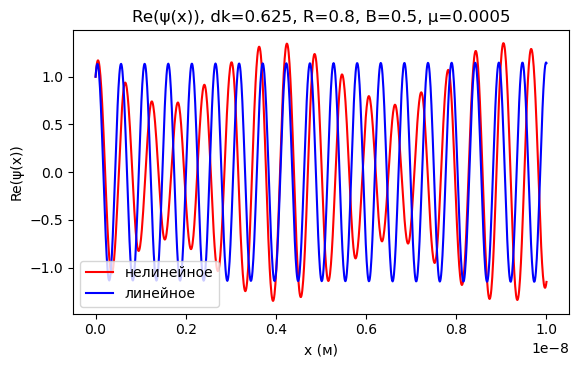

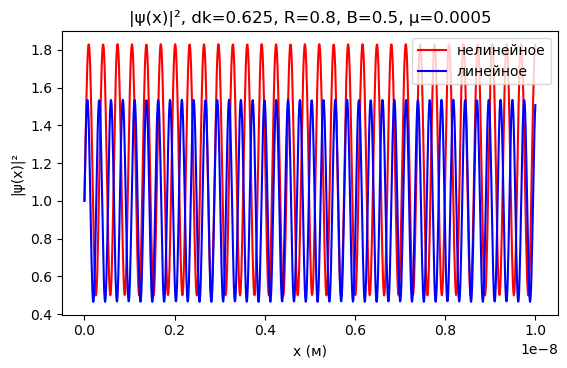

In [94]:
t = sol_fast['t']
y = sol_fast["y"][0]
t0= sol_fast_0['t']
y0= sol_fast_0['y'][0]

fig, ax = plt.subplots()

ax.set_ylabel('Re(ψ(x))')
ax.set_xlabel('x (м)')

plt.title(f"Re(ψ(x)), dk={dk}, R={R}, B={B}, \u03BC={mu}")

h_list = []

line1, = ax.plot(np.real(t), np.real(y), color = 'red', label = 'нелинейное')
h_list.append(line1)
line2, = ax.plot(np.real(t0), np.real(y0), color = 'blue', label = 'линейное')
h_list.append(line2)


ax.legend(handles=h_list)
ax.set_box_aspect(2.0/3.5)

plt.savefig("fastoscre.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)


fig, ax = plt.subplots()

ax.set_ylabel('|ψ(x)|\u00b2')
ax.set_xlabel('x (м)')

plt.title(f"|ψ(x)|\u00b2, dk={dk}, R={R}, B={B}, \u03BC={mu}")

h_list = []

line3, = ax.plot(np.abs(t), np.power(np.abs(y),2), color = 'red', label = 'нелинейное')
h_list.append(line3)
line4, = ax.plot(np.abs(t0), np.power(np.abs(y0),2), color = 'blue', label = 'линейное')
h_list.append(line4)
#ax.plot(np.abs(t), 0.67*np.sin(1.94e10 * np.abs(t)-0.1)+1.17)

ax.legend(handles=h_list)
ax.set_box_aspect(2.0/3.5)

plt.savefig("fastoscabs.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

In [96]:
len(y)

1024

In [74]:
y_sh = y[:-1]

In [83]:
len(y_sh)/2

2914.0

In [ ]:
freq = np.linspace(0.0, 1.0/(2*dx), N//2)

In [137]:
dx = t[1]-t[0]
freq = 2*pi*np.linspace(-1.0/(2*dx), 1.0/(2*dx), 1024)

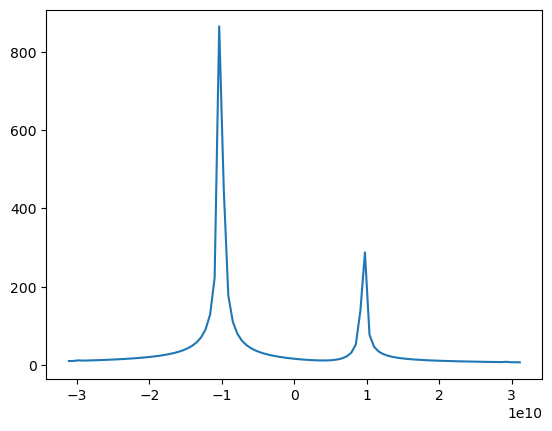

In [146]:
fig, ax = plt.subplots()
nnn = 50

line3, = ax.plot(freq[512-nnn:512+nnn], np.abs(out3[512-nnn:512+nnn]))

#line3, = ax.plot(freq[512-nnn:512+nnn],np.real(out3[512-nnn:512+nnn]))
#line3, = ax.plot(freq[512-nnn:512+nnn],np.imag(out3[512-nnn:512+nnn]))


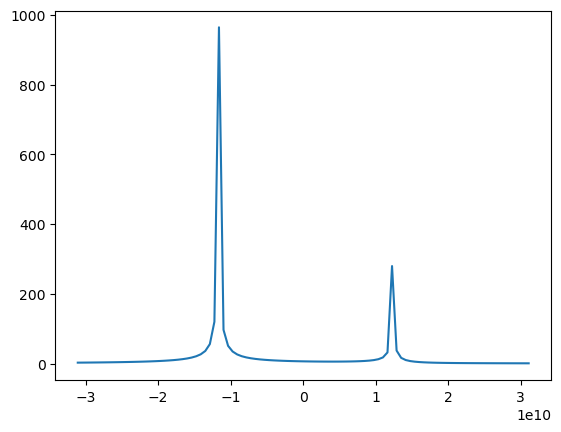

In [147]:
fig, ax = plt.subplots()
nnn = 50

line3, = ax.plot(freq[512-nnn:512+nnn], np.abs(out4[512-nnn:512+nnn]))

#line3, = ax.plot(freq[512-nnn:512+nnn],np.real(out4[512-nnn:512+nnn]))
#line3, = ax.plot(freq[512-nnn:512+nnn],np.imag(out4[512-nnn:512+nnn]))

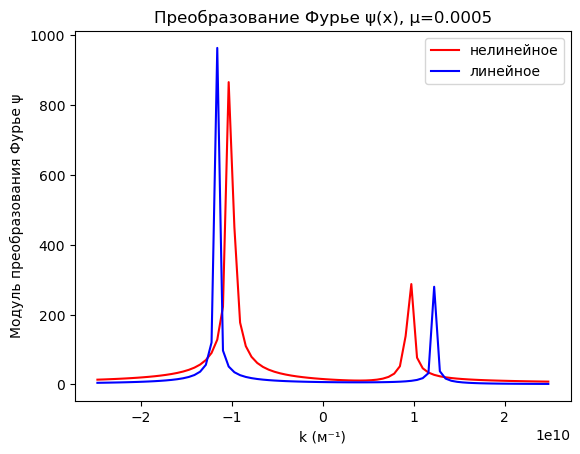

In [150]:
fig, ax = plt.subplots()
nnn = 40

ax.set_ylabel('Модуль преобразования Фурье ψ')
ax.set_xlabel('k (м\u207b\u00b9)')

plt.title(f"Преобразование Фурье ψ(x), \u03BC={mu}")


line3, = ax.plot(freq[512-nnn:512+nnn], np.abs(out3[512-nnn:512+nnn]), color = 'red', label = 'нелинейное')
line3, = ax.plot(freq[512-nnn:512+nnn], np.abs(out4[512-nnn:512+nnn]), color = 'blue', label = 'линейное')

plt.legend()

plt.savefig("fourier.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

In [142]:
np.argmax(np.abs(out3[:512])), np.argmax(np.abs(out4[:512])),np.argmax(np.abs(out3[512:])),np.argmax(np.abs(out4[512:]))

(495, 493, 15, 19)

In [145]:
19+493, 15+495

(512, 510)

In [141]:
freq[495]

-10367255756.846317

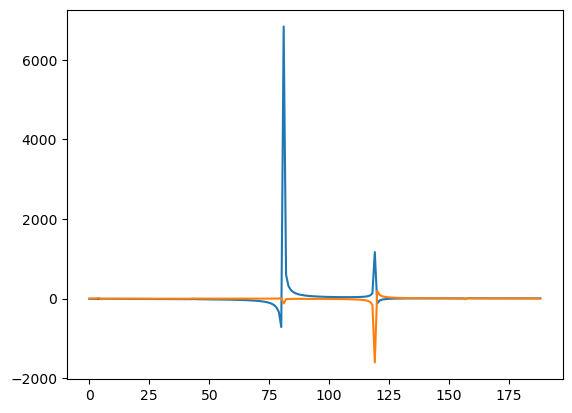

In [89]:
fig, ax = plt.subplots()

line3, = ax.plot(np.real(out4[3511:3700]))
line3, = ax.plot(np.imag(out4[3511:3700]))


In [97]:
out1 = scipy.fft.fft(y)
out2 = scipy.fft.fft(y0)

In [45]:
amp = np.max(np.abs(np.real(y)))

In [31]:
arr_ar = np.real(y[1:])*np.real(y[:-1])

In [ ]:
np.are

In [33]:
from eelib.fitted_functions import find_root_points

In [35]:
root_ls = find_root_points(np.real(y))

In [36]:
root_ls

[119, 304, 488, 673]

In [37]:
y1_list = np.real(y)

In [38]:
y1_list[root_ls[0]+1]

-0.006875530876856193

In [39]:
rt_start = root_ls[1]

In [40]:
t_list = np.real(t)

In [42]:
t_root_list = []
for i in root_ls:
    t_root_list.append(t_list[i])
    

In [43]:

t_diff = np.array(t_root_list[1:])- np.array(t_root_list[:-1])
t_dif_ave = np.average(t_diff) * 2


In [44]:
t_dif_ave

5.368584968217536e-10

In [49]:
import scipy

In [46]:
MM = 2 * pi / t_dif_ave
theta = - MM * t_list[rt_start] # Rescale our x_0 to be an angle shift.

# Prevent our function fitter from deviating too far from our expected values.
amp_tol = 0.1
M_tol = 0.1
th_tol = 0.1 * pi

# Minimum, maximum, and starting values for our function fitter, in the correct form.
min_arr = np.array([(1.0 - amp_tol) * amp, MM - M_tol * MM , theta - th_tol])
max_arr = np.array([(1.0 + 2 * amp_tol) * amp, MM + M_tol * MM, theta + th_tol])
start_arr = np.array([amp, MM, theta])


In [48]:
popt, pcov = scipy.optimize.curve_fit(eelib.sin_fit, np.real(t), np.real(y), p0=start_arr, bounds=(min_arr, max_arr))


In [49]:
popt

array([ 1.12357139e+00,  1.17206853e+10, -5.22270627e+00])

In [50]:
pcov

array([[ 2.18986969e-07,  1.69053305e+01,  3.28699809e-10],
       [ 1.69053305e+01,  2.16759270e+12, -1.15169375e+03],
       [ 3.28699809e-10, -1.15169375e+03,  7.86120498e-07]])

In [ ]:
t = sol_fast['t']
y = sol_fast["y"][0]
t0= sol_fast_0['t']
y0= sol_fast_0['y'][0]

In [118]:
trim

16

In [133]:
np.average(np.abs(sol_fast['y_events'][0][1::2,0])), np.std(np.abs(sol_fast['y_events'][0][1::2,0]))

(0.7059647750682605, 1.195355570351812e-11)

In [136]:
np.average(np.abs(sol_fast_0['y_events'][0][1::2,0])), np.std(np.abs(sol_fast_0['y_events'][0][1::2,0]))

(0.6815995882263873, 8.29254387249582e-12)

In [134]:
np.average(np.abs(sol_fast['y_events'][0][::2,0])), np.std(np.abs(sol_fast['y_events'][0][::2,0]))

(1.3528194402695193, 1.2278953173281197e-11)

In [135]:
np.average(np.abs(sol_fast_0['y_events'][0][::2,0])), np.std(np.abs(sol_fast_0['y_events'][0][::2,0]))

(1.2391214634756758, 1.5108173738891505e-11)

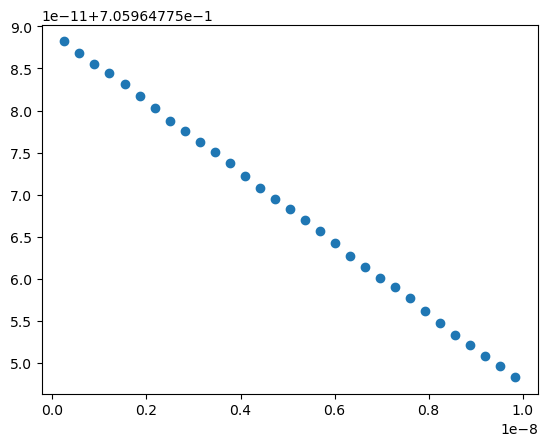

In [131]:
fig, ax = plt.subplots()
ax.scatter(sol_fast['t_events'][0][1::2], np.abs(sol_fast['y_events'][0][1::2,0]))

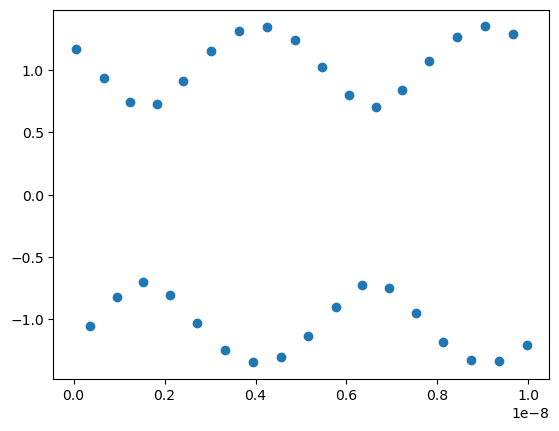

In [127]:
fig, ax = plt.subplots()
ax.scatter(sol_fast['t_events'][1], sol_fast['y_events'][1][:,0])

In [122]:
sol_fast['y_events'][1][1:]

array([[-1.05998993e+00+5.93204825e-01j, -1.22799894e+00+9.55617738e+09j],
       [ 9.39223774e-01-6.00296851e-01j,  1.60888335e+00-1.07858983e+10j],
       [-8.26154955e-01+5.12420788e-01j, -1.43032692e+00+1.22634946e+10j],
       [ 7.41617943e-01-3.14590486e-01j, -2.96776258e+01-1.36629874e+10j],
       [-7.06249817e-01+2.95410097e-02j,  4.06002382e+03+1.43480480e+10j],
       [ 7.30431305e-01+2.64684077e-01j,  3.78441580e+03-1.38724816e+10j],
       [-8.06938812e-01-4.82870738e-01j,  1.03007288e+00+1.25558305e+10j],
       [ 9.16219193e-01+5.91450840e-01j,  5.76421758e+01-1.10569418e+10j],
       [-1.03694390e+00-6.00843250e-01j,  2.11680861e+00+9.76871233e+09j],
       [ 1.15157208e+00+5.34456546e-01j, -1.07201634e+00-8.79572688e+09j],
       [-1.24719808e+00-4.14189105e-01j, -8.76442074e+01+8.12096989e+09j],
       [ 1.31491246e+00+2.58168129e-01j, -8.55992029e+03-7.70255789e+09j],
       [-1.34914299e+00-8.18708300e-02j, -2.46504010e+04+7.50703352e+09j],
       [ 1.34725883e+00-1

In [ ]:
tuerr = np.real(sol_fast['t_events'][1][0::trim])
tlerr = np.real(sol_fast['t_events'][1][1::trim])

tu0rr = np.real(sol_r0['t_events'][1][0::trim])


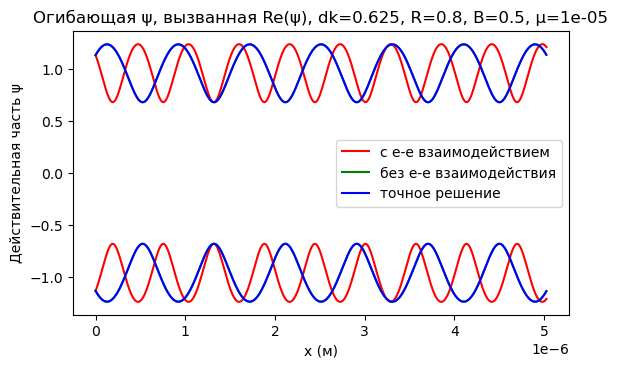

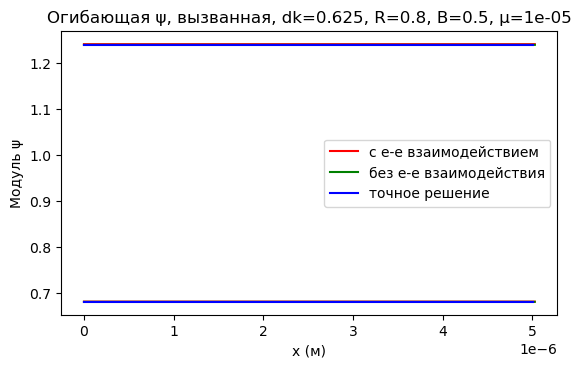

In [28]:

# массивы положений
# оцененные, вызванные |psi|, вызванные Re(psi) -- c, a, r
tuerr = np.real(sol_re['t_events'][1][0::trim])
tu0rr = np.real(sol_r0['t_events'][1][0::trim])
tuedr = np.real(sol_de['t_events'][1][0::trim])
tu0dr = np.real(sol_d0['t_events'][1][0::trim])
tlerr = np.real(sol_re['t_events'][1][1::trim])
tl0rr = np.real(sol_r0['t_events'][1][1::trim])
tledr = np.real(sol_de['t_events'][1][1::trim])
tl0dr = np.real(sol_d0['t_events'][1][1::trim])

# вызваны |psi|
tuera = np.real(sol_re['t_events'][0][0::trim])
tu0ra = np.real(sol_r0['t_events'][0][0::trim])
tueda = np.real(sol_de['t_events'][0][0::trim])
tu0da = np.real(sol_d0['t_events'][0][0::trim])
tlera = np.real(sol_re['t_events'][0][1::trim])
tl0ra = np.real(sol_r0['t_events'][0][1::trim])
tleda = np.real(sol_de['t_events'][0][1::trim])
tl0da = np.real(sol_d0['t_events'][0][1::trim])

# массивы значений
suerr = np.real(sol_re['y_events'][1][0::trim, 0])
suedr = np.real(sol_de['y_events'][1][0::trim, 0])
slerr = np.real(sol_re['y_events'][1][1::trim, 0])
sledr = np.real(sol_de['y_events'][1][1::trim, 0])
su0rr = np.real(sol_r0['y_events'][1][0::trim, 0])
su0dr = np.real(sol_d0['y_events'][1][0::trim, 0])
sl0rr = np.real(sol_r0['y_events'][1][1::trim, 0])
sl0dr = np.real(sol_d0['y_events'][1][1::trim, 0])

# вызваны |psi|
suera = np.real(sol_re['y_events'][0][0::trim, 0])
sueda = np.real(sol_de['y_events'][0][0::trim, 0])
slera = np.real(sol_re['y_events'][0][1::trim, 0])
sleda = np.real(sol_de['y_events'][0][1::trim, 0])
su0ra = np.real(sol_r0['y_events'][0][0::trim, 0])
su0da = np.real(sol_d0['y_events'][0][0::trim, 0])
sl0ra = np.real(sol_r0['y_events'][0][1::trim, 0])
sl0da = np.real(sol_d0['y_events'][0][1::trim, 0])

# точные решения
tu0xc = np.real(sol_0x_u_tc)
tl0xc = np.real(sol_0x_l_tc)
su0xc = np.real(sol_0x_u_yc)
sl0xc = np.real(sol_0x_l_yc)
tu0xr = np.real(sol_0x_u_tr)
tl0xr = np.real(sol_0x_l_tr)
su0xr = np.real(sol_0x_u_yr)
sl0xr = np.real(sol_0x_l_yr)

#-- ПОСТРОЙКА ГРАФИКОВ --


# Это также вызванное максимумами действительных значений и также
# использует эти вычисленные точки в качестве точек, в которых
# вычисляется точное решение. Это гарантирует, что точное решение также
# будет иметь форму огибающей, а не синусоиды.
fig, ax = plt.subplots()
ax.set_ylabel('Действительная часть \u03C8')
ax.set_xlabel('x (м)')
plt.title(f"Огибающая \u03C8, вызванная Re(\u03C8), dk={dk}, R={R}, B={B}, \u03BC={mu}")

h_list = []


#line1, = ax.plot(tuerr, suerr, color = 'red', label = 'с e-e взаимодействием, восстановлено')
#line2, = ax.plot(tlerr, slerr, color = 'red', label = 'с e-e взаимодействием, восстановлено')
#h_list.append(line1)

line3, = ax.plot(tuedr, suedr, color = 'red', label = 'с e-e взаимодействием')
line4, = ax.plot(tledr, sledr, color = 'red', label = 'с e-e взаимодействием')
h_list.append(line3)

#line5, = ax.plot(tu0rr, su0rr, color = 'green', label = 'без e-e взаимодействия, восстановлено')
#line6, = ax.plot(tl0rr, sl0rr, color = 'green', label = 'без e-e взаимодействия, восстановлено')
#h_list.append(line5)

line7, = ax.plot(tu0dr, su0dr, color = 'green', label = 'без e-e взаимодействия')
line8, = ax.plot(tl0dr, sl0dr, color = 'green', label = 'без e-e взаимодействия')
h_list.append(line7)
line9, = ax.plot(tu0xr, su0xr, color = 'blue', label = 'точное решение')
line10, = ax.plot(tl0xr, sl0xr, color = 'blue', label = 'точное решение')
h_list.append(line9)

ax.legend(handles=h_list)
ax.set_box_aspect(2.0/3.5)

plt.savefig("realEnv2.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

# --- ГРАФИКИ МОДУЛЯ ---

tuera = np.abs(sol_re['t_events'][0][0::trim])
tu0ra = np.abs(sol_r0['t_events'][0][0::trim])
tueda = np.abs(sol_de['t_events'][0][0::trim])
tu0da = np.abs(sol_d0['t_events'][0][0::trim])
tlera = np.abs(sol_re['t_events'][0][1::trim])
tl0ra = np.abs(sol_r0['t_events'][0][1::trim])
tleda = np.abs(sol_de['t_events'][0][1::trim])
tl0da = np.abs(sol_d0['t_events'][0][1::trim])

# Попробовать также построить графики вычисляемых версий. 
# Точность расчета видна по убыванию того, что должно быть прямой линией.
tuerc = np.abs(sol_re['t'])
tu0rc = np.abs(sol_r0['t'])

# массивы значений
suera = np.abs(sol_re['y_events'][0][0::trim, 0])
sueda = np.abs(sol_de['y_events'][0][0::trim, 0])
slera = np.abs(sol_re['y_events'][0][1::trim, 0])
sleda = np.abs(sol_de['y_events'][0][1::trim, 0])
su0ra = np.abs(sol_r0['y_events'][0][0::trim, 0])
su0da = np.abs(sol_d0['y_events'][0][0::trim, 0])
sl0ra = np.abs(sol_r0['y_events'][0][1::trim, 0])
sl0da = np.abs(sol_d0['y_events'][0][1::trim, 0])

# Попробовать также построить графики вычисляемых версий.
suerc = np.abs(sol_re['y'][0])
su0rc = np.abs(sol_r0['y'][0])

# точные решения
tu0xa = np.abs(sol_0x_u_tc)
tl0xa = np.abs(sol_0x_l_tc)
su0xa = np.abs(sol_0x_u_yc)
sl0xa = np.abs(sol_0x_l_yc)

# --- огибающая, вызвана |psi| ---
fig, ax = plt.subplots()
ax.set_ylabel('Модуль \u03C8')
ax.set_xlabel('x (м)')
plt.title(f"Огибающая \u03C8, вызванная, dk={dk}, R={R}, B={B}, \u03BC={mu}")

h_list = []


#line1, = ax.plot(tuera, suera, color = 'red', label = 'с e-e взаимодействием, восстановлено')
#line2, = ax.plot(tlera, slera, color = 'red', label = 'с e-e взаимодействием, восстановлено')
#h_list.append(line1)

line3, = ax.plot(tueda, sueda, color = 'red', label = 'с e-e взаимодействием')
line4, = ax.plot(tleda, sleda, color = 'red', label = 'с e-e взаимодействием')
h_list.append(line3)

#line5, = ax.plot(tu0ra, su0ra, color = 'green', label = 'без e-e взаимодействия, восстановлено')
#line6, = ax.plot(tl0ra, sl0ra, color = 'green', label = 'без e-e взаимодействия, восстановлено')
#h_list.append(line5)

line7, = ax.plot(tu0da, su0da, color = 'green', label = 'без e-e взаимодействия')
line8, = ax.plot(tl0da, sl0da, color = 'green', label = 'без e-e взаимодействия')
h_list.append(line7)
line9, = ax.plot(tu0xa, su0xa, color = 'blue', label = 'точное решение')
line10, = ax.plot(tl0xa, sl0xa, color = 'blue', label = 'точное решение')
h_list.append(line9)

ax.legend(handles=h_list)

ax.set_box_aspect(2.0/3.5)

plt.savefig("absEnv2.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

In [24]:
np.max(su0xa)-np.min(su0xa)

3.3306690738754696e-16

In [25]:
np.max(su0da)-np.min(su0da), np.max(sl0da)-np.min(sl0da), np.max(su0ra)-np.min(su0ra)

(2.645376029342117e-08, 1.4508748980013308e-08, 6.613389835763428e-10)

In [26]:
np.max(sueda)-np.min(sueda), np.max(sleda)-np.min(sleda), np.max(sl0ra)-np.min(sl0ra)

(2.6647407835866943e-08, 1.4718924190582072e-08, 3.573618068131168e-10)

In [27]:
np.max(suera)-np.min(suera), np.max(slera)-np.min(slera)

(8.314950949994682e-10, 3.628897182750279e-10)

In [34]:
np.average(su0da), np.std(su0da), np.average(su0ra), np.std(su0ra)

(1.2391214502742938,
 7.639719749468303e-09,
 1.2391214631986611,
 1.5463122874523664e-10)

In [33]:
np.average(sl0da), np.std(sl0da), np.average(sl0ra), np.std(sl0ra)

(0.681599580985965,
 4.1900766857533685e-09,
 0.6815995880981999,
 8.441172579910324e-11)

In [36]:
np.average(sueda), np.std(sueda), np.average(suera), np.std(suera)

(1.2406015060288882,
 7.695654240495503e-09,
 1.2406015191773072,
 1.6519773850415315e-10)

In [35]:
np.average(sleda), np.std(sleda), np.average(slera), np.std(slera)

(0.6820671502793884,
 4.250793618999796e-09,
 0.6820671574809509,
 8.602734046225982e-11)

In [29]:
import sklearn.metrics as mtc

In [31]:
mtc.mean_absolute_percentage_error(su0ra, su0da)

1.0430267104162631e-08

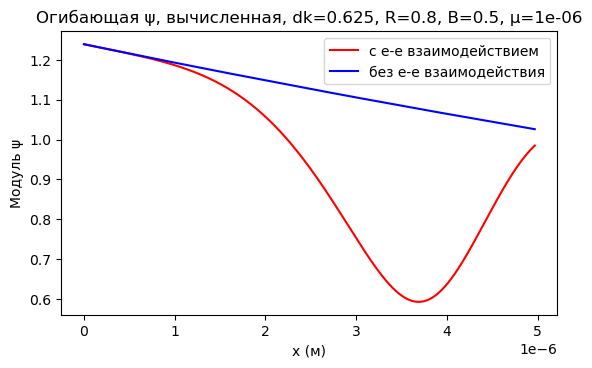

In [19]:

# массивы положений
# оцененные, вызванные |psi|, вызванные Re(psi) -- c, a, r
tedr = np.real(sol_slow2['t'])
t0dr = np.real(sol_slow0['t'])


# вызваны |psi|
sera = np.real(sol_slow2['y'][0])
s0ra = np.real(sol_slow0['y'][0])

# точные решения
#tu0xc = np.real(sol_0x_u_tc)
#su0xc = np.real(sol_0x_u_yc)
#tu0xr = np.real(sol_0x_u_tr)
#su0xr = np.real(sol_0x_u_yr)

#-- ПОСТРОЙКА ГРАФИКОВ --

# --- ГРАФИКИ МОДУЛЯ ---

tera = np.abs(sol_re['t'])
t0ra = np.abs(sol_r0['t'])
teda = np.abs(sol_de['t'])
t0da = np.abs(sol_d0['t'])


# Попробовать также построить графики вычисляемых версий. 
# Точность расчета видна по убыванию того, что должно быть прямой линией.
terc = np.abs(sol_slow2['t'])
t0rc = np.abs(sol_slow1['t'])

# массивы значений
seda = np.abs(sol_slow2['y'][0])
s0da = np.abs(sol_slow1['y'][0])

# точные решения
tu0xa = np.abs(sol_0x_u_tc)
tl0xa = np.abs(sol_0x_l_tc)
su0xa = np.abs(sol_0x_u_yc)
sl0xa = np.abs(sol_0x_l_yc)


# ---- ПОСТРОЙКА ГРАФИКОВ ----
# --- вычислено ---
fig, ax = plt.subplots()
ax.set_ylabel('Модуль \u03C8')
ax.set_xlabel('x (м)')
plt.title(f"Огибающая \u03C8, вычисленная, dk={dk}, R={R}, B={B}, \u03BC={mu}")

h_list = []

line1, = ax.plot(terc, seda, color = 'red', label = 'с e-e взаимодействием')
#line1, = ax.plot(terc, seda, color = 'red', label = 'с e-e взаимодействием')
h_list.append(line1)

line5, = ax.plot(t0rc, s0da, color = 'blue', label = 'без e-e взаимодействия')
h_list.append(line5)
#line9, = ax.plot(tu0xa, su0xa, color = 'purple', label = 'точное решение')
#line10, = ax.plot(tl0xa, sl0xa, color = 'purple', label = 'точное решение')
#h_list.append(line9)

ax.legend(handles=h_list)
ax.set_box_aspect(2.0/3.5)

plt.savefig("phaseError1.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)